In [2]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from adjustText import adjust_text

In [3]:
raw_expressions = pd.read_csv('raw_expression_cells.tsv', sep='\t', index_col=0)

raw_expressions

,HCT_WT2,SW837D,R1-1,HCT_WT3,SW837,HCT116,HCT_WT1,SW620,R1-2,R1-3
ENSG00000223972,0,0,0,1,0,0,0,0,0,0
ENSG00000227232,84,5,0,141,51,150,142,196,0,2
ENSG00000278267,5,0,1,1,3,9,2,9,3,4
ENSG00000243485,0,0,0,0,0,0,0,0,0,0
ENSG00000284332,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
ENSG00000271254,474,171,186,789,975,716,1013,511,143,136
ENSG00000275405,105,6,0,36,25,16,128,44,1,1
ENSG00000275987,0,1,0,0,5,0,1,0,0,0
ENSG00000277475,1,0,0,0,1,0,0,0,0,0


In [4]:
raw_expressions.rename(columns = {'R1-1': 'HCT-15-4', 
                                     'R1-2': 'HCT-15-5',
                                     'R1-3': 'HCT-15-6',
                                     'HCT_WT1': 'HCT-15-1',
                                     'HCT_WT2': 'HCT-15-2',
                                     'HCT_WT3': 'HCT-15-3',
                                    }, inplace = True)

In [5]:
mean_gene_lenghts = pd.read_csv('gene_length.tsv', sep = '\t', index_col=0)['median_trna_lenght']
mean_gene_lenghts

Gene_id
ENSG00000223972    1140.0
ENSG00000227232    1340.0
ENSG00000278267      67.0
ENSG00000243485     621.0
ENSG00000284332     137.0
                    ...  
ENSG00000271254    2500.0
ENSG00000275405     163.0
ENSG00000275987     143.0
ENSG00000277475     830.0
ENSG00000268674     509.0
Name: median_trna_lenght, Length: 58233, dtype: float64

In [6]:
dataset_normalized = raw_expressions.copy()

for gene in dataset_normalized.index:
    dataset_normalized.loc[gene] = dataset_normalized.loc[gene]/mean_gene_lenghts[gene]*10**3
    
dataset_normalized = dataset_normalized.apply(lambda x: x/x.sum()*10**6)

dataset_normalized

/tmp/ipykernel_33363/1499405756.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.8771929824561404' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dataset_normalized.loc[gene] = dataset_normalized.loc[gene]/mean_gene_lenghts[gene]*10**3
/tmp/ipykernel_33363/1499405756.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '62.6865671641791' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dataset_normalized.loc[gene] = dataset_normalized.loc[gene]/mean_gene_lenghts[gene]*10**3
/tmp/ipykernel_33363/1499405756.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3.7313432835820897' has dtype incompatible with int64, please explicitly cast to a compatible dtype fir

,HCT-15-2,SW837D,HCT-15-4,HCT-15-3,SW837,HCT116,HCT-15-1,SW620,HCT-15-5,HCT-15-6
ENSG00000223972,0.000000,0.000000,0.000000,0.047122,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000227232,3.551290,0.615897,0.000000,5.652492,1.150944,3.039267,4.218097,3.913663,0.000000,0.114496
ENSG00000278267,4.227726,0.000000,1.007039,0.801772,1.354052,3.647120,1.188196,3.594180,3.292991,4.579826
ENSG00000243485,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000284332,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
ENSG00000271254,10.741130,11.290132,5.019887,16.953629,11.793792,7.775985,16.128813,5.469065,4.206687,4.173138
ENSG00000275405,36.493315,6.075843,0.000000,11.864258,4.638112,2.665108,31.257579,7.222661,0.451187,0.470626
ENSG00000275987,0.000000,1.154269,0.000000,0.000000,1.057360,0.000000,0.278354,0.000000,0.000000,0.000000
ENSG00000277475,0.068255,0.000000,0.000000,0.000000,0.036434,0.000000,0.000000,0.000000,0.000000,0.000000


/tmp/ipykernel_33363/509991403.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pca_res = pca.fit_transform(dataset_normalized.applymap(lambda x: np.log10(x+1)).T).T


Text(0.5, 1.0, 'PCA of log(TPM) expression values')

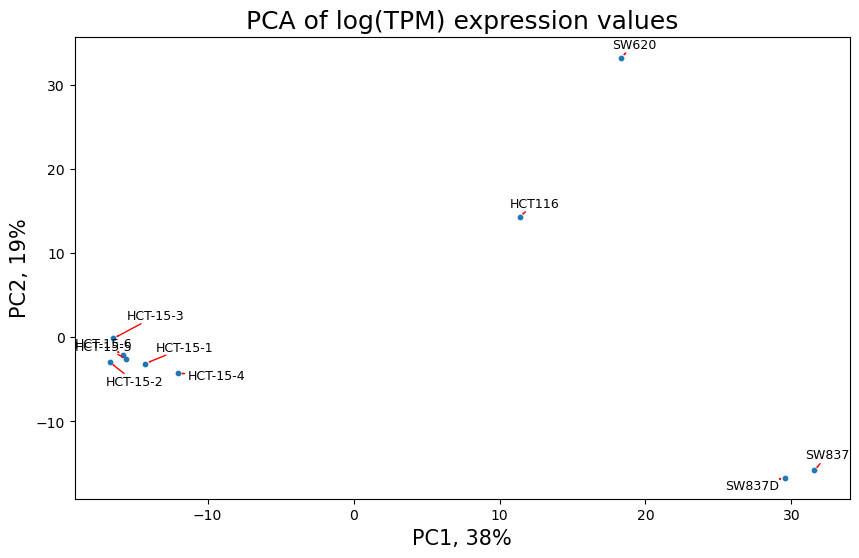

In [9]:
plt.figure(figsize=(10, 6))

pca = PCA(n_components=2)
pca_res = pca.fit_transform(dataset_normalized.applymap(lambda x: np.log10(x+1)).T).T
plt.scatter(pca_res[0], pca_res[1], s = 10)

expl_var = pca.explained_variance_ratio_

# Add labels and legend
plt.xlabel(f'PC1, {round(expl_var[0]*100)}%', fontsize=15)
plt.ylabel(f'PC2, {round(expl_var[1]*100)}%', fontsize=15)

annotations = []

for i, label in enumerate(dataset_normalized.columns):
    annotations.append(plt.text(pca_res[0][i], pca_res[1][i], label.split('_S')[0], fontsize=9, ha='right'))

adjust_text(annotations, expand=(1.2, 2), arrowprops=dict(arrowstyle='->', color='red'))

plt.title('PCA of log(TPM) expression values', fontsize=18)

/tmp/ipykernel_33363/530930672.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data_log = dataset_normalized.applymap(lambda x: np.log10(x + 1))
/home/khokholmongolll/miniconda3/envs/ml/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/khokholmongolll/miniconda3/envs/ml/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


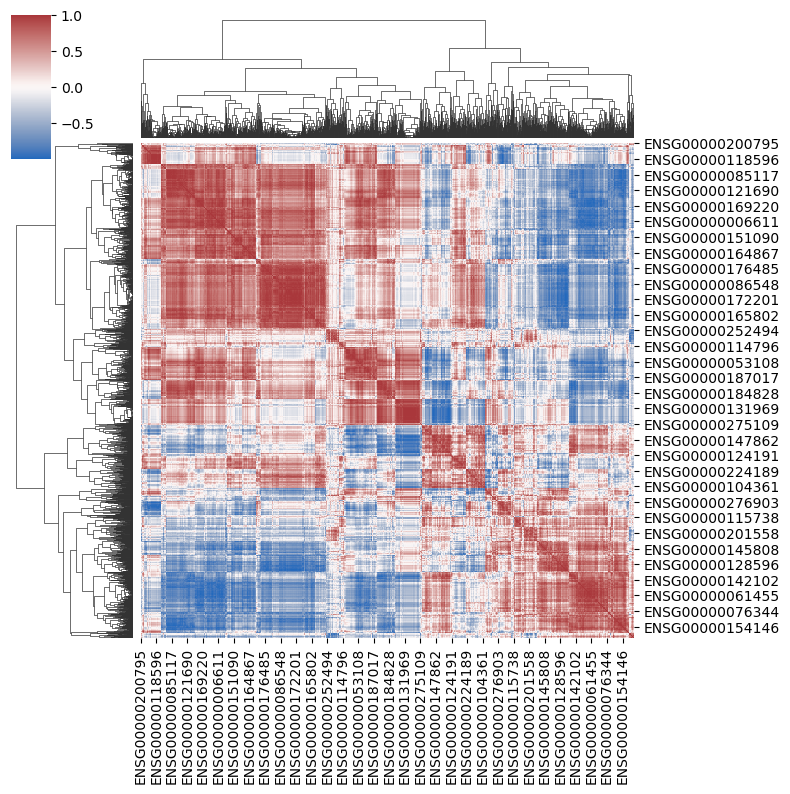

In [ ]:
data_log = dataset_normalized.applymap(lambda x: np.log10(x + 1))

top_genes = data_log.var(axis=1).sort_values(ascending=False).head(2000).index
data_top = data_log.loc[top_genes]

data_samples = data_top.T
corr = data_samples.corr(method="pearson")

sns.clustermap(
    corr,
    figsize=(8, 8),
    cmap="vlag",
    metric="euclidean",
    method="average"
)

/home/khokholmongolll/miniconda3/envs/ml/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/khokholmongolll/miniconda3/envs/ml/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


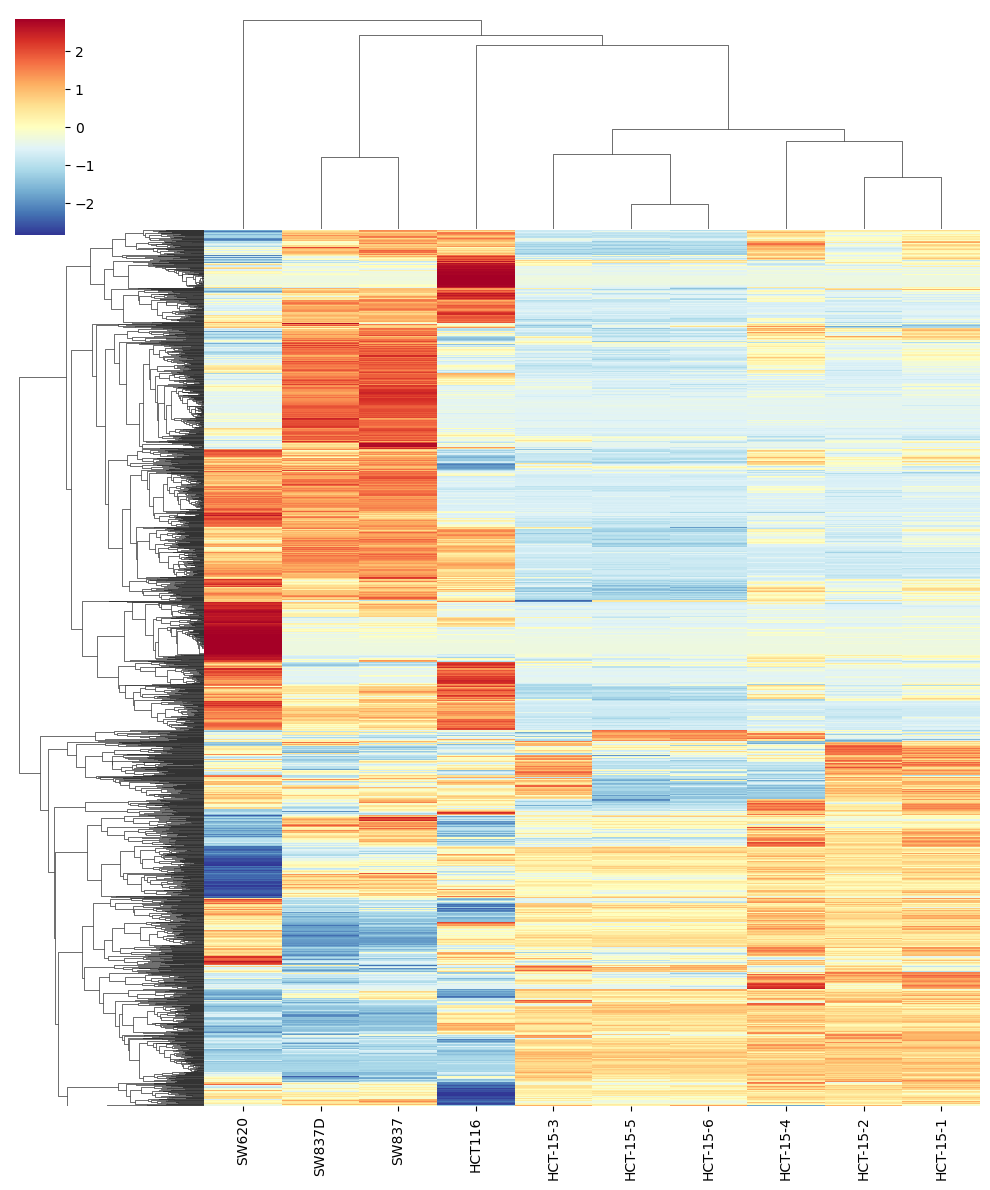

In [11]:
sns.clustermap(
        data_top,
        figsize=(10, 12),
        cmap="RdYlBu_r", # Красный (high) -> Синий (low)
        z_score=0,       # Считает (x - mean)/std для каждого гена
        yticklabels=False, # Убираем названия 2000 генов, чтобы не захламлять
     xticklabels=True
    )

/home/khokholmongolll/miniconda3/envs/ml/lib/python3.12/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/khokholmongolll/miniconda3/envs/ml/lib/python3.12/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


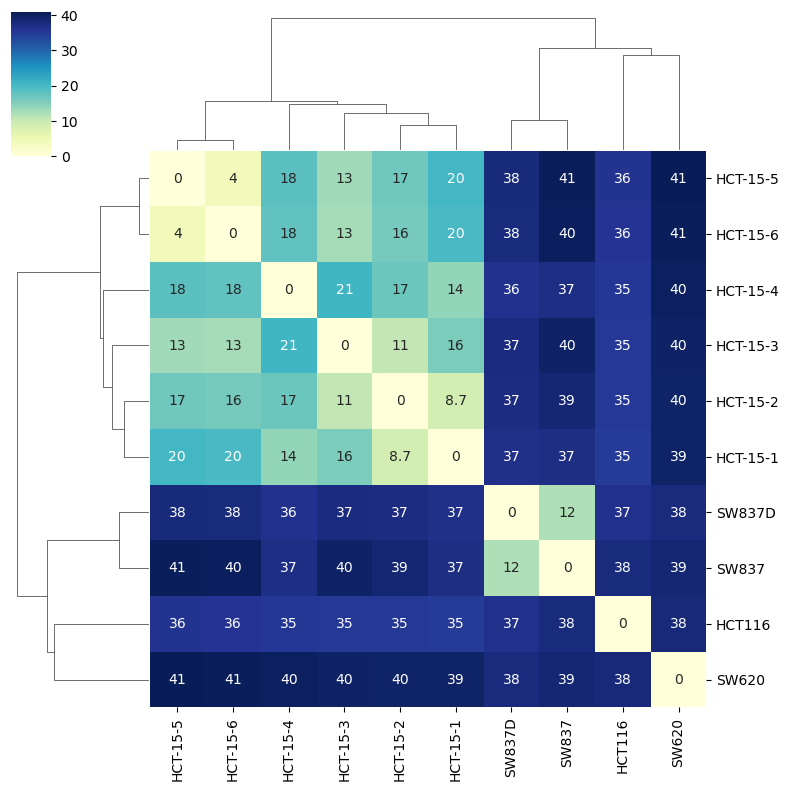

In [13]:
from scipy.spatial.distance import pdist, squareform
distances = pdist(data_top.T, metric='euclidean')
dist_matrix = pd.DataFrame(squareform(distances), index=data_top.columns, columns=data_top.columns)
sns.clustermap(
    dist_matrix,
    figsize=(8, 8),
    cmap="YlGnBu", # Светлый (близко) -> Темный (далеко)
    annot=True     # Выведет числа (расстояния) в ячейках
    )

/home/khokholmongolll/miniconda3/envs/ml/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/khokholmongolll/miniconda3/envs/ml/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


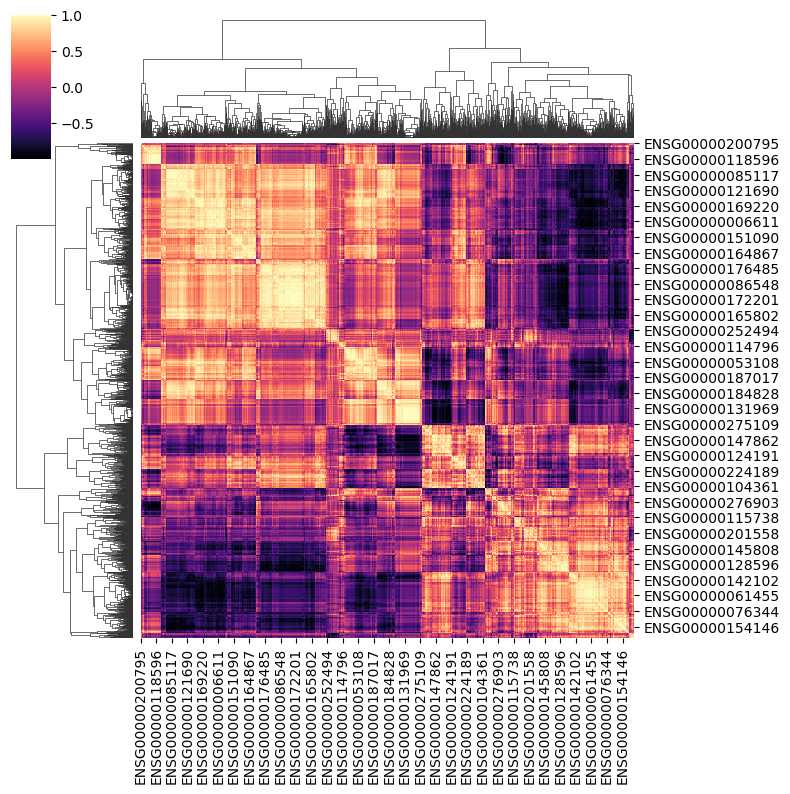

In [14]:
sns.clustermap(
    corr,
    figsize=(8, 8),
    cmap="magma",
    metric="euclidean",
    method="average"
)